<a href="https://colab.research.google.com/github/anusreeakumar-ai/Predictive-Stroke-Risk-Analysis/blob/main/Anusree_A_Kumar(3)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
# Ignore warnings to keep output clean
warnings.filterwarnings("ignore")

In [ ]:
# Load the stroke dataset
data=pd.read_csv("/content/healthcare-dataset-stroke-data.csv")
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
# Check how many missing values are in each column
data.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
# Fill missing values in the 'bmi' column with its mean
mean=data['bmi'].mean()
data['bmi'].fillna(mean,inplace=True)
# Re-check for missing values
data.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
# Convert categorical data to numeric using Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder
od_enc=OrdinalEncoder()
# Encode all categorical columns
data["gender"]=od_enc.fit_transform(data[["gender"]])
data["ever_married"]=od_enc.fit_transform(data[["ever_married"]])
data["work_type"]=od_enc.fit_transform(data[["work_type"]])
data["Residence_type"]=od_enc.fit_transform(data[["Residence_type"]])
data["smoking_status"]=od_enc.fit_transform(data[["smoking_status"]])
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1.0,67.0,0,1,1.0,2.0,1.0,228.69,36.600000,1.0,1
1,51676,0.0,61.0,0,0,1.0,3.0,0.0,202.21,28.893237,2.0,1
2,31112,1.0,80.0,0,1,1.0,2.0,0.0,105.92,32.500000,2.0,1
3,60182,0.0,49.0,0,0,1.0,2.0,1.0,171.23,34.400000,3.0,1
4,1665,0.0,79.0,1,0,1.0,3.0,0.0,174.12,24.000000,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0.0,80.0,1,0,1.0,2.0,1.0,83.75,28.893237,2.0,0
5106,44873,0.0,81.0,0,0,1.0,3.0,1.0,125.20,40.000000,2.0,0
5107,19723,0.0,35.0,0,0,1.0,3.0,0.0,82.99,30.600000,2.0,0
5108,37544,1.0,51.0,0,0,1.0,2.0,0.0,166.29,25.600000,1.0,0


In [ ]:
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1.0,67.0,0,1,1.0,2.0,1.0,228.69,36.600000,1.0,1
1,51676,0.0,61.0,0,0,1.0,3.0,0.0,202.21,28.893237,2.0,1
2,31112,1.0,80.0,0,1,1.0,2.0,0.0,105.92,32.500000,2.0,1
3,60182,0.0,49.0,0,0,1.0,2.0,1.0,171.23,34.400000,3.0,1
4,1665,0.0,79.0,1,0,1.0,3.0,0.0,174.12,24.000000,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0.0,80.0,1,0,1.0,2.0,1.0,83.75,28.893237,2.0,0
5106,44873,0.0,81.0,0,0,1.0,3.0,1.0,125.20,40.000000,2.0,0
5107,19723,0.0,35.0,0,0,1.0,3.0,0.0,82.99,30.600000,2.0,0
5108,37544,1.0,51.0,0,0,1.0,2.0,0.0,166.29,25.600000,1.0,0


In [ ]:
# Drop 'id' column since it's not a useful feature
data.drop(['id'],axis=1,inplace=True)
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.0,67.0,0,1,1.0,2.0,1.0,228.69,36.600000,1.0,1
1,0.0,61.0,0,0,1.0,3.0,0.0,202.21,28.893237,2.0,1
2,1.0,80.0,0,1,1.0,2.0,0.0,105.92,32.500000,2.0,1
3,0.0,49.0,0,0,1.0,2.0,1.0,171.23,34.400000,3.0,1
4,0.0,79.0,1,0,1.0,3.0,0.0,174.12,24.000000,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,0.0,80.0,1,0,1.0,2.0,1.0,83.75,28.893237,2.0,0
5106,0.0,81.0,0,0,1.0,3.0,1.0,125.20,40.000000,2.0,0
5107,0.0,35.0,0,0,1.0,3.0,0.0,82.99,30.600000,2.0,0
5108,1.0,51.0,0,0,1.0,2.0,0.0,166.29,25.600000,1.0,0


In [ ]:
# Features (X): all columns except the target
x=data.iloc[:,:-1]
x

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1.0,67.0,0,1,1.0,2.0,1.0,228.69,36.600000,1.0
1,0.0,61.0,0,0,1.0,3.0,0.0,202.21,28.893237,2.0
2,1.0,80.0,0,1,1.0,2.0,0.0,105.92,32.500000,2.0
3,0.0,49.0,0,0,1.0,2.0,1.0,171.23,34.400000,3.0
4,0.0,79.0,1,0,1.0,3.0,0.0,174.12,24.000000,2.0
...,...,...,...,...,...,...,...,...,...,...
5105,0.0,80.0,1,0,1.0,2.0,1.0,83.75,28.893237,2.0
5106,0.0,81.0,0,0,1.0,3.0,1.0,125.20,40.000000,2.0
5107,0.0,35.0,0,0,1.0,3.0,0.0,82.99,30.600000,2.0
5108,1.0,51.0,0,0,1.0,2.0,0.0,166.29,25.600000,1.0


In [ ]:
# Target (y): the 'stroke' column
y=data.iloc[:,-1]
y

,stroke
0,1
1,1
2,1
3,1
4,1
...,...
5105,0
5106,0
5107,0
5108,0


In [ ]:
# Scale all features to [0, 1] range
from sklearn.preprocessing import MinMaxScaler
m=MinMaxScaler()
x_m=m.fit_transform(x)
x_m

array([[0.5       , 0.81689453, 0.        , ..., 0.80126489, 0.30126002,
        0.33333333],
       [0.        , 0.74365234, 0.        , ..., 0.67902317, 0.21298095,
        0.66666667],
       [0.5       , 0.97558594, 0.        , ..., 0.23451205, 0.25429553,
        0.66666667],
       ...,
       [0.        , 0.42626953, 0.        , ..., 0.12865848, 0.2325315 ,
        0.66666667],
       [0.5       , 0.62158203, 0.        , ..., 0.51320284, 0.17525773,
        0.33333333],
       [0.        , 0.53613281, 0.        , ..., 0.13922999, 0.18213058,
        0.        ]])

In [ ]:
from sklearn.model_selection import train_test_split
# Split into 70% training and 30% testing data
x_train,x_test,y_train,y_test=train_test_split(x_m,y,test_size=0.3,random_state=1)

In [ ]:
# Print shapes for confirmation
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3577, 10)
(1533, 10)
(3577,)
(1533,)


Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1450
           1       0.19      0.43      0.27        83

    accuracy                           0.87      1533
   macro avg       0.58      0.66      0.60      1533
weighted avg       0.92      0.87      0.89      1533



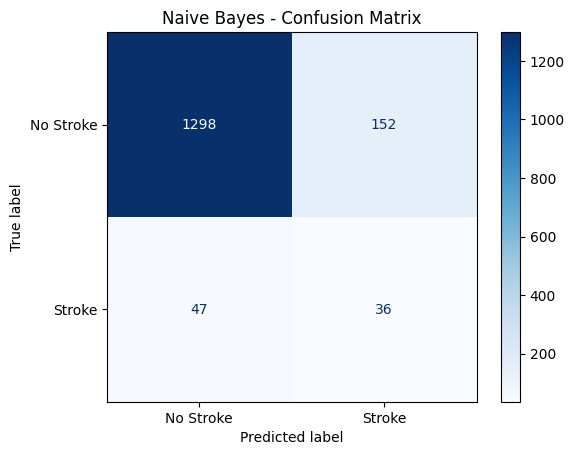

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Initialize and train the Naive Bayes model
nb = GaussianNB()
nb.fit(x_train, y_train)
# Predict stroke outcomes on test data
y_nb = nb.predict(x_test)
# Print evaluation metrics
print("Classification Report:\n")
print(classification_report(y_test, y_nb))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_nb, display_labels=['No Stroke', 'Stroke'], cmap='Blues')
plt.title("Naive Bayes - Confusion Matrix")
plt.grid(False)
plt.show()

In [ ]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.0,67.0,0,1,1.0,2.0,1.0,228.69,36.600000,1.0,1
1,0.0,61.0,0,0,1.0,3.0,0.0,202.21,28.893237,2.0,1
2,1.0,80.0,0,1,1.0,2.0,0.0,105.92,32.500000,2.0,1
3,0.0,49.0,0,0,1.0,2.0,1.0,171.23,34.400000,3.0,1
4,0.0,79.0,1,0,1.0,3.0,0.0,174.12,24.000000,2.0,1


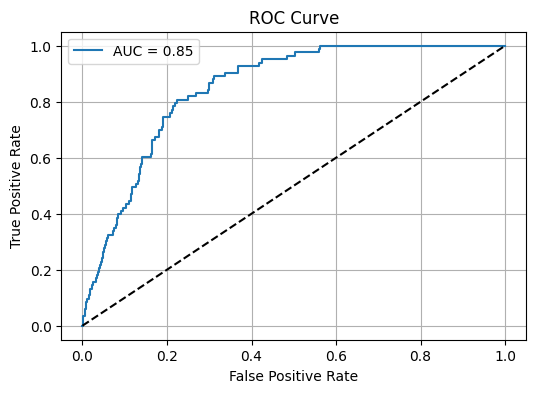

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)
import numpy as np

#  ROC Curve
# Note: y_kt must be predicted probabilities, not just labels
# Get predicted probabilities for the positive class (stroke)
y_probs = nb.predict_proba(x_test)[:, 1]  # Probabilities for the positive class

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot the ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

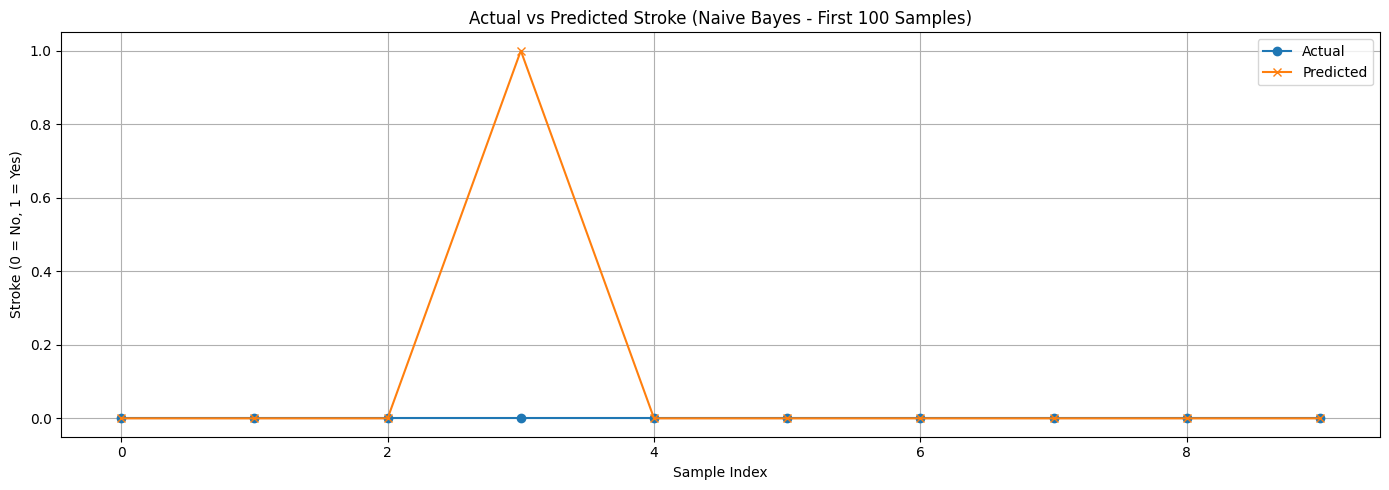

In [ ]:
import matplotlib.pyplot as plt
# Convert y_test to a NumPy array
y_test_array = y_test.values
# Number of samples to plot
n_samples = 10
plt.figure(figsize=(14, 5))
plt.plot(range(n_samples), y_test[:n_samples], label='Actual', marker='o')
plt.plot(range(n_samples), y_nb[:n_samples], label='Predicted', marker='x')
# Plot the first 10 predictions
plt.title('Actual vs Predicted Stroke (Naive Bayes - First 100 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Stroke (0 = No, 1 = Yes)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
y_new=nb.predict(m.transform([[1.0, 67.0, 0, 1, 1.0, 2.0, 1.0, 228.69, 36.6, 1.0]]))
y_new

if (y_new==0):
  print("✅   No Stroke Risk Detected.")
else:
  print("⚠️ High Risk Of Stroke! Please consult a Healthcare Provider")

⚠️ High Risk Of Stroke! Please consult a Healthcare Provider


In [ ]:
# -------------------------
# User Input
# -------------------------

gender = input("Enter Gender (Female/Male/Other): ")
ever_married = input("Ever Married? (Yes/No): ")
work_type = input("Work Type (children/Govt_job/Never_worked/Private/Self-employed): ")
residence_type = input("Residence Type (Rural/Urban): ")
smoking_status = input("Smoking Status (formerly smoked/never smoked/smokes/Unknown): ")

# Numerical Inputs
age = float(input("Enter Age (e.g., 67.0): "))
hypertension = int(input("Hypertension (0 = No, 1 = Yes): "))
heart_disease = int(input("Heart Disease (0 = No, 1 = Yes): "))
avg_glucose_level = float(input("Average Glucose Level (e.g., 228.69): "))
bmi = float(input("BMI (e.g., 36.6): "))

# -------------------------
# Manual Encoding
# -------------------------

# gender: ['Female', 'Male', 'Other']
if gender == 'Female':
    gender_num = 0
elif gender == 'Male':
    gender_num = 1
else:
    gender_num = 2

# ever_married: ['No', 'Yes']
ever_married_num = 0 if ever_married == 'No' else 1

# work_type: ['children', 'Govt_job', 'Never_worked', 'Private', 'Self-employed']
work_type_map = {
    'children': 0,
    'Govt_job': 1,
    'Never_worked': 2,
    'Private': 3,
    'Self-employed': 4
}
work_type_num = work_type_map.get(work_type, 3)  # default to 'Private'

# residence_type: ['Rural', 'Urban']
residence_num = 0 if residence_type == 'Rural' else 1

# smoking_status: ['formerly smoked', 'never smoked', 'smokes', 'Unknown']
smoking_map = {
    'formerly smoked': 0,
    'never smoked': 1,
    'smokes': 2,
    'Unknown': 3
}
smoking_num = smoking_map.get(smoking_status, 3)  # default to 'Unknown'

# -------------------------
# Final Input Preparation
# -------------------------

new_input = [[
    gender_num, age, hypertension, heart_disease, ever_married_num,
    work_type_num, residence_num, avg_glucose_level, bmi, smoking_num
]]

# -------------------------
# Scaling Input
# -------------------------
new_scaled =m.transform(new_input)

# -------------------------
# Predict using Trained Model
# -------------------------
y_new = nb.predict(new_scaled)[0]

# -------------------------
# Result
# -------------------------
if y_new == 0:
    print("✅ No Stroke Risk Detected.")
else:
    print("⚠️ High Risk of Stroke! Please consult a Healthcare Provider.")